In [1]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from transformers import AutoProcessor, AutoModelForVision2Seq
from PIL import Image
import torch
import requests


2025-04-27 14:10:08.860479: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745763008.875013       9 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745763008.879645       9 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-27 14:10:08.897107: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# Usa la GPU si está disponible
device = "cuda" if torch.cuda.is_available() else "cpu"


# model_name = "Salesforce/blip-image-captioning-base"
# processor = BlipProcessor.from_pretrained(model_name)
# model = BlipForConditionalGeneration.from_pretrained(model_name)

model_name = "Salesforce/blip2-opt-2.7b"
processor = Blip2Processor.from_pretrained(model_name)
# model = Blip2ForConditionalGeneration.from_pretrained(model_name, torch_dtype=torch.float16, device_map="auto")
# model = Blip2ForConditionalGeneration.from_pretrained(model_name, torch_dtype=torch.float16, device_map={"": 0})
model = Blip2ForConditionalGeneration.from_pretrained(model_name, torch_dtype=torch.float16, load_in_8bit=True,device_map={"": 0})

# model_name = "microsoft/git-base"
# processor = AutoProcessor.from_pretrained(model_name)
# model = AutoModelForVision2Seq.from_pretrained(model_name)





Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [12]:
model.to(device)

You shouldn't move a model that is dispatched using accelerate hooks.


RuntimeError: You can't move a model that has some modules offloaded to cpu or disk.

In [25]:
# url = "https://i.redd.it/u372z8loi7xe1.jpeg"
url = "https://i.redd.it/vtjpqriz4axe1.png"
# url = "https://i.redd.it/u2smvl331axe1.jpeg"
# url = "https://i.redd.it/vgy37xvi39xe1.jpeg"
# url = "https://i.redd.it/hsny4knu18xe1.png"
# url = "https://i.redd.it/1epklvyd48xe1.jpeg"
# url = "https://media.sproutsocial.com/uploads/meme-example.jpg"
# url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)
# image = Image.open(image_path).convert('RGB')


In [ ]:
image.save("./memes/geeks.jpg")

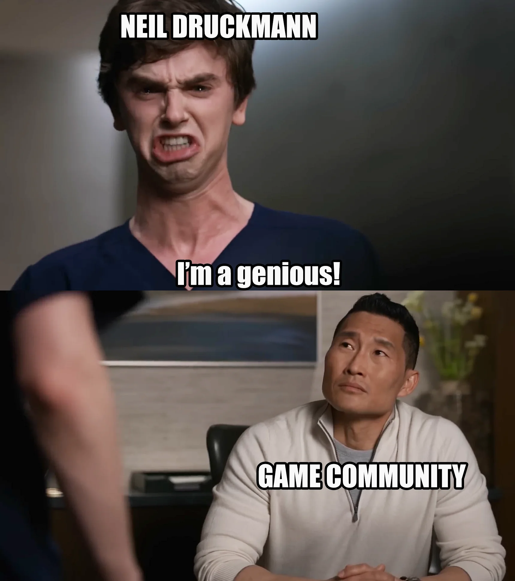

In [26]:
width, height = image.size
percentage = 30  # Example: resize to 50%
new_width = int(width * (percentage / 100))
new_height = int(height * (percentage / 100))
img_resized = image.resize((new_width, new_height))
display(img_resized)

In [29]:
prompt = "Question: Describe this image with as much detail as possible, including the scene, objects, people, colors, text, and any possible actions or emotions? Answer:"

In [30]:
# Preprocesa la imagen
# inputs = processor(images=image,text=prompt, return_tensors="pt").to(device)
inputs = processor(images=image,text=prompt, return_tensors="pt").to(device="cuda", dtype=torch.float16)

# inputs = {k: v.to(device) for k, v in inputs.items()}

# Genera el caption
with torch.no_grad():
    # generated_ids = model.generate(**inputs, max_length=500)
    generated_ids = model.generate(**inputs)
    # caption = processor.decode(generated_ids[0], skip_special_tokens=True)

# Decodifica
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

# print(f"\n🔹 Caption generado: {caption}")
print(f"\n🔹 Caption generado: {generated_text}")


🔹 Caption generado: Question: Describe this image with as much detail as possible, including the scene, objects, people, colors, text, and any possible actions or emotions? Answer: Neelix is a genius, game community



In [31]:
import torch
import requests
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration

processor = Blip2Processor.from_pretrained("sashakunitsyn/vlrm-blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained("sashakunitsyn/vlrm-blip2-opt-2.7b", torch_dtype=torch.float16, device_map="auto")


preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/708 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

...

model-00003-of-00008.safetensors:   0%|          | 0.00/985M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Some parameters are on the meta device because they were offloaded to the cpu.
Expanding inputs for image tokens in BLIP-2 should be done in processing. Please follow instruction here (https://gist.github.com/zucchini-nlp/e9f20b054fa322f84ac9311d9ab67042) to update your BLIP-2 model. Using processors without these attributes in the config is deprecated and will throw an error in v4.50.
Both `max_new_tokens` (=60) and `max_length`(=51) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.11/site-packages/transformers/generation/utils.py:2347: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cuda, whereas the model is on meta. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` 

'a woman in a plaid shirt shaking hands with a yellow labrador retriever sitting on the ground at sunset on a beach in florida'

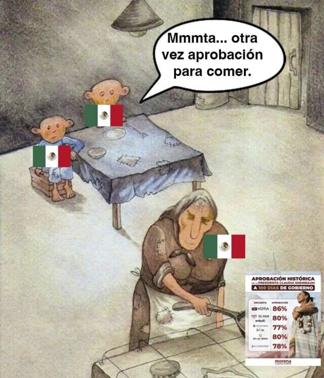

In [40]:
# url = "https://i.redd.it/u372z8loi7xe1.jpeg"
# url = "https://i.redd.it/vtjpqriz4axe1.png"
# url = "https://i.redd.it/u2smvl331axe1.jpeg"
# url = "https://i.redd.it/vgy37xvi39xe1.jpeg"
url = "https://i.redd.it/hsny4knu18xe1.png"
# url = "https://i.redd.it/1epklvyd48xe1.jpeg"
# url = "https://media.sproutsocial.com/uploads/meme-example.jpg"
# url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)
# image = Image.open(image_path).convert('RGB')
width, height = image.size
percentage = 30  # Example: resize to 50%
new_width = int(width * (percentage / 100))
new_height = int(height * (percentage / 100))
img_resized = image.resize((new_width, new_height))
display(img_resized)

In [42]:
image.save("./memes/aprobacion.jpg")

In [41]:
# img_url = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg'
# img_url = "https://i.redd.it/vtjpqriz4axe1.png"
# raw_image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

inputs = processor(image, return_tensors="pt").to("cuda", torch.float16)

# out = model.generate(**inputs)
out = model.generate(**inputs, max_new_tokens=1000,max_length=1000)
processor.decode(out[0], skip_special_tokens=True).strip()
# 'a woman in a plaid shirt shaking hands with a yellow labrador retriever sitting on the ground at sunset on a beach in florida'

Both `max_new_tokens` (=1000) and `max_length`(=1031) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


'an old woman and a baby trying to cook on a tablecloth in front of a poster with the words “momma” written in mexican accent'